In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
# === PHẢI ĐẶT TRƯỚC MỌI THAO TÁC TF ===
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️ CPU mode")

import time, pickle, warnings, gc, json as _json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, OrderedDict
from math import pi

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout, Flatten,
    Bidirectional, SpatialDropout1D, GlobalMaxPooling1D,
    GlobalAveragePooling1D, BatchNormalization, Concatenate,
    Conv1D, Add, LayerNormalization, MultiHeadAttention, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"TensorFlow: {tf.__version__}")

✅ GPU: /physical_device:GPU:0
TensorFlow: 2.20.0


In [3]:

TCN_DIR  = '/content/drive/MyDrive/MalwareDetection/TCN_V2/'
PKL_PATH = f'{TCN_DIR}/sequences_deduped_full.pkl'
CSV_PATH = '/content/feature_vectors_syscalls_frequency_5_Cat.csv'
SAVE_DIR = '/content/drive/MyDrive/MalwareDetection/MultiModel_Results/'

os.makedirs(f'{SAVE_DIR}/figures', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/models', exist_ok=True)

MAX_LEN    = 512
BATCH_SIZE = 64
EPOCHS     = 50
PATIENCE   = 7
TEST_SIZE  = 0.20

print("Config loaded")

Config loaded


In [4]:
with open(PKL_PATH, 'rb') as f:
    compact = pickle.load(f)

encoded_data = compact['encoded_data']
vocab        = compact['vocab']
token2idx    = compact['token2idx']
VOCAB_SIZE   = len(vocab)
PAD_IDX      = token2idx['<PAD>']

all_tokens = [d['tokens'] for d in encoded_data]
all_labels = np.array([d['label_binary'] for d in encoded_data])

print(f'Total samples:  {len(encoded_data):,}')
print(f'Vocab size:     {VOCAB_SIZE}')
print(f'Label dist:     Benign={np.sum(all_labels==0):,}, Malware={np.sum(all_labels==1):,}')

X_seq = pad_sequences(all_tokens, maxlen=MAX_LEN, padding='pre',
                      truncating='post', value=PAD_IDX)
Y_seq = all_labels

X_train_seq, X_test_seq, Y_train_seq, Y_test_seq = train_test_split(
    X_seq, Y_seq, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=Y_seq)

Y_train_cat = to_categorical(Y_train_seq, 2)
Y_test_cat  = to_categorical(Y_test_seq, 2)

print(f'Train: {X_train_seq.shape[0]:,}  |  Test: {X_test_seq.shape[0]:,}')

Total samples:  9,449
Vocab size:     111
Label dist:     Benign=1,251, Malware=8,198
Train: 7,559  |  Test: 1,890


In [5]:
df_csv = pd.read_csv(CSV_PATH)
print(f"CSV shape: {df_csv.shape}")
print(f"5-class distribution:\n{df_csv['Class'].value_counts().sort_index()}")

X_csv = df_csv.drop('Class', axis=1).values
y_csv_5class = df_csv['Class'].values.astype(int)

# Binary: Class 3 = Benign (0), rest = Malware (1)
y_csv_binary = np.where(y_csv_5class == 3, 0, 1)
print(f"\nBinary: Benign={np.sum(y_csv_binary==0):,}, Malware={np.sum(y_csv_binary==1):,}")

scaler = StandardScaler()
X_csv_scaled = scaler.fit_transform(X_csv)

X_train_csv, X_test_csv, Y_train_csv, Y_test_csv = train_test_split(
    X_csv_scaled, y_csv_binary, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y_csv_binary)

print(f"ML Train: {X_train_csv.shape[0]:,}  |  ML Test: {X_test_csv.shape[0]:,}")

CSV shape: (11598, 140)
5-class distribution:
Class
1.0    1253
2.0    2100
3.0    3904
4.0    2546
5.0    1795
Name: count, dtype: int64

Binary: Benign=3,904, Malware=7,694
ML Train: 9,278  |  ML Test: 2,320


In [6]:
def build_lstm_original(vocab_size, max_len):
    model = Sequential()
    model.add(Embedding(vocab_size, 16, input_length=max_len))
    model.add(LSTM(100, activation='softsign', return_sequences=True,
                   recurrent_activation='sigmoid'))
    model.add(Dropout(0.2))
    model.add(LSTM(100, activation='softsign'))
    model.add(Flatten())
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
def build_lstm_improved(vocab_size, max_len):
    inp = Input(shape=(max_len,))
    x = Embedding(vocab_size, 64)(inp)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = Concatenate()([avg_pool, max_pool])
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(2, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [8]:
class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='gelu'), Dense(d_model)])
        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout_rate)
        self.drop2 = Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        x = self.ln1(x + attn_out)
        ffn_out = self.ffn(x, training=training)
        ffn_out = self.drop2(ffn_out, training=training)
        x = self.ln2(x + ffn_out)
        return x


def build_malbert(vocab_size, max_len, d_model=64, num_heads=4,
                  ff_dim=128, num_blocks=2, dropout=0.1):
    inp = Input(shape=(max_len,))
    tok_emb = Embedding(vocab_size, d_model)(inp)
    pos_emb = Embedding(max_len, d_model)(tf.range(max_len))
    x = tok_emb + pos_emb
    x = Dropout(dropout)(x)
    for i in range(num_blocks):
        x = TransformerEncoderBlock(d_model, num_heads, ff_dim, dropout,
                                    name=f'enc_block_{i}')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(2, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [14]:
class TCNResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, dilation_rate, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = Conv1D(filters, kernel_size, padding='causal',
                           dilation_rate=dilation_rate, activation='relu')
        self.conv2 = Conv1D(filters, kernel_size, padding='causal',
                           dilation_rate=dilation_rate, activation='relu')
        self.drop1 = Dropout(dropout_rate)
        self.drop2 = Dropout(dropout_rate)
        self.ln = LayerNormalization()
        self.match_conv = None
        self.filters = filters

    def build(self, input_shape):
        if input_shape[-1] != self.filters:
            self.match_conv = Conv1D(self.filters, 1)
        super().build(input_shape)

    def call(self, x, training=False):
        residual = x
        out = self.conv1(x)
        out = self.drop1(out, training=training)
        out = self.conv2(out)
        out = self.drop2(out, training=training)
        if self.match_conv is not None:
            residual = self.match_conv(residual)
        return self.ln(out + residual)


class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(shape=(d, d), name='att_W', initializer='glorot_uniform')
        self.b = self.add_weight(shape=(d,),    name='att_b', initializer='zeros')
        self.u = self.add_weight(shape=(d,),    name='att_u', initializer='glorot_uniform')
        super().build(input_shape)

    def call(self, x):
        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        weights = tf.nn.softmax(tf.tensordot(score, self.u, axes=1), axis=1)
        return tf.reduce_sum(x * tf.expand_dims(weights, -1), axis=1)


def build_tcn_att(vocab_size, max_len, emb_dim=64, num_filters=64,
                  kernel_size=3, dilations=[1, 2, 4, 8, 16], dropout=0.1):
    inp = Input(shape=(max_len,))
    x = Embedding(vocab_size, emb_dim)(inp)
    x = SpatialDropout1D(0.1)(x)
    for i, d in enumerate(dilations):
        x = TCNResidualBlock(num_filters, kernel_size, d, dropout,
                            name=f'tcn_{i}')(x)
    x = AttentionLayer(name='attention')(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(2, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [12]:
def train_and_evaluate_dl(build_fn, model_name, X_train, Y_train_cat,
                         X_test, Y_test, Y_test_cat, save_dir,
                         epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE):
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")
    model = build_fn()
    model.build(input_shape=(None, X_train.shape[1]))  # ← Thêm dòng này
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
    ]
    t0 = time.time()
    history = model.fit(X_train, Y_train_cat, validation_split=0.15,
                        epochs=epochs, batch_size=batch_size,
                        callbacks=callbacks, verbose=1)
    train_time = time.time() - t0

    Y_pred_prob = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_prob, axis=1)
    Y_prob_pos = Y_pred_prob[:, 1]

    acc  = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec  = recall_score(Y_test, Y_pred)
    f1   = f1_score(Y_test, Y_pred)
    auc  = roc_auc_score(Y_test, Y_prob_pos)
    n_params = model.count_params()

    print(f"  ✅ {model_name}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Time={train_time:.1f}s")

    model.save(f"{save_dir}/models/{model_name.replace(' ', '_')}.keras")

    return {
        'model_name': model_name,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc,
        'train_time': train_time, 'n_params': n_params,
        'Y_pred': Y_pred, 'Y_prob': Y_prob_pos,
        'history': history.history,
    }

In [16]:
dl_results = OrderedDict()

dl_results['LSTM Gốc'] = train_and_evaluate_dl(
    lambda: build_lstm_original(VOCAB_SIZE, MAX_LEN),
    'LSTM Gốc', X_train_seq, Y_train_cat,
    X_test_seq, Y_test_seq, Y_test_cat, SAVE_DIR)

dl_results['LSTM Cải tiến'] = train_and_evaluate_dl(
    lambda: build_lstm_improved(VOCAB_SIZE, MAX_LEN),
    'LSTM Cải tiến', X_train_seq, Y_train_cat,
    X_test_seq, Y_test_seq, Y_test_cat, SAVE_DIR)

dl_results['MalBERT'] = train_and_evaluate_dl(
    lambda: build_malbert(VOCAB_SIZE, MAX_LEN, d_model=64, num_heads=4, ff_dim=128, num_blocks=2),
    'MalBERT', X_train_seq, Y_train_cat,
    X_test_seq, Y_test_seq, Y_test_cat, SAVE_DIR)

dl_results['TCN-ATT'] = train_and_evaluate_dl(
    lambda: build_tcn_att(VOCAB_SIZE, MAX_LEN, emb_dim=64, num_filters=64,
                          kernel_size=3, dilations=[1, 2, 4, 8, 16]),
    'TCN-ATT', X_train_seq, Y_train_cat,
    X_test_seq, Y_test_seq, Y_test_cat, SAVE_DIR)

print("\nDL models done!")


  Training: LSTM Gốc


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 512, 16)        │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 512, 100)       │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,178 (504.60 KB)

 Trainable params: 129,178 (504.60 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (None, 512, 64)        │         7,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 512, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_0 (TCNResidualBlock)        │ (None, 512, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCNResidualBlock)        │ (None, 512, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCNResidualBlock)        │ (None, 512, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCNResidualBlock)        │ (None, 512, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_4 (TCNResidualBlock)        │ (None, 512, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,778 (546.01 KB)

 Trainable params: 139,778 (546.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 55s 238ms/step - accuracy: 0.8878 - loss: 0.3200 - val_accuracy: 0.9303 - val_loss: 0.2156 - learning_rate: 0.0010
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9331 - loss: 0.1955 - val_accuracy: 0.9409 - val_loss: 0.1691 - learning_rate: 0.0010
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9438 - loss: 0.1636 - val_accuracy: 0.9541 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9538 - loss: 0.1368 - val_accuracy: 0.9533 - val_loss: 0.1480 - learning_rate: 0.0010
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9581 - loss: 0.1204 - val_accuracy: 0.9541 - val_loss: 0.1433 - learning_rate: 0.0010
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9620 - loss: 0.1076 - val_accuracy: 0.9586 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9672 - loss: 

In [17]:
def train_and_evaluate_ml(clf, model_name, X_train, Y_train, X_test, Y_test):
    print(f"\n{'='*60}")
    print(f"   Training: {model_name}")
    print(f"{'='*60}")
    t0 = time.time()
    clf.fit(X_train, Y_train)
    train_time = time.time() - t0

    Y_pred = clf.predict(X_test)
    Y_prob_pos = clf.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec  = recall_score(Y_test, Y_pred)
    f1   = f1_score(Y_test, Y_pred)
    auc  = roc_auc_score(Y_test, Y_prob_pos)

    print(f"   {model_name}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Time={train_time:.1f}s")
    return {
        'model_name': model_name,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc,
        'train_time': train_time, 'n_params': 'N/A',
        'Y_pred': Y_pred, 'Y_prob': Y_prob_pos, 'history': None,
    }

ml_results = OrderedDict()

ml_results['Random Forest'] = train_and_evaluate_ml(
    RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5,
                           class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest', X_train_csv, Y_train_csv, X_test_csv, Y_test_csv)

ml_results['XGBoost'] = train_and_evaluate_ml(
    xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                       subsample=0.8, colsample_bytree=0.8,
                       scale_pos_weight=np.sum(Y_train_csv==0)/max(np.sum(Y_train_csv==1),1),
                       eval_metric='logloss', random_state=RANDOM_STATE,
                       n_jobs=-1, tree_method='hist'),
    'XGBoost', X_train_csv, Y_train_csv, X_test_csv, Y_test_csv)

print("\nML models done!")


   Training: Random Forest
   Random Forest: Acc=0.9888  F1=0.9916  AUC=0.9985  Time=0.9s

   Training: XGBoost
   XGBoost: Acc=0.9914  F1=0.9935  AUC=0.9978  Time=0.8s

ML models done!


In [18]:
all_results = OrderedDict()
all_results.update(dl_results)
all_results.update(ml_results)

# Y_test mapping cho mỗi model
test_labels = {}
for name in dl_results: test_labels[name] = Y_test_seq
for name in ml_results: test_labels[name] = Y_test_csv

metrics_table = []
for name, res in all_results.items():
    metrics_table.append({
        'Model': name, 'Accuracy': res['accuracy'], 'Precision': res['precision'],
        'Recall': res['recall'], 'F1-Score': res['f1'], 'AUC': res['auc'],
        'Train Time (s)': round(res['train_time'], 1),
        'Params': f"{res['n_params']:,}" if res['n_params'] != 'N/A' else 'N/A',
    })

df_results = pd.DataFrame(metrics_table)
print(df_results.to_string(index=False, float_format='%.4f'))
df_results.to_csv(f"{SAVE_DIR}/comparison_results.csv", index=False)

        Model  Accuracy  Precision  Recall  F1-Score    AUC  Train Time (s)  Params
     LSTM Gốc    0.9228     0.9303  0.9848    0.9568 0.8320        347.5000 129,178
LSTM Cải tiến    0.9688     0.9759  0.9884    0.9821 0.9859        133.9000 271,170
      MalBERT    0.9275     0.9397  0.9793    0.9591 0.9538        170.8000  78,338
      TCN-ATT    0.9593     0.9694  0.9841    0.9767 0.9804         69.0000 139,778
Random Forest    0.9888     0.9884  0.9948    0.9916 0.9985          0.9000     N/A
      XGBoost    0.9914     0.9929  0.9942    0.9935 0.9978          0.8000     N/A


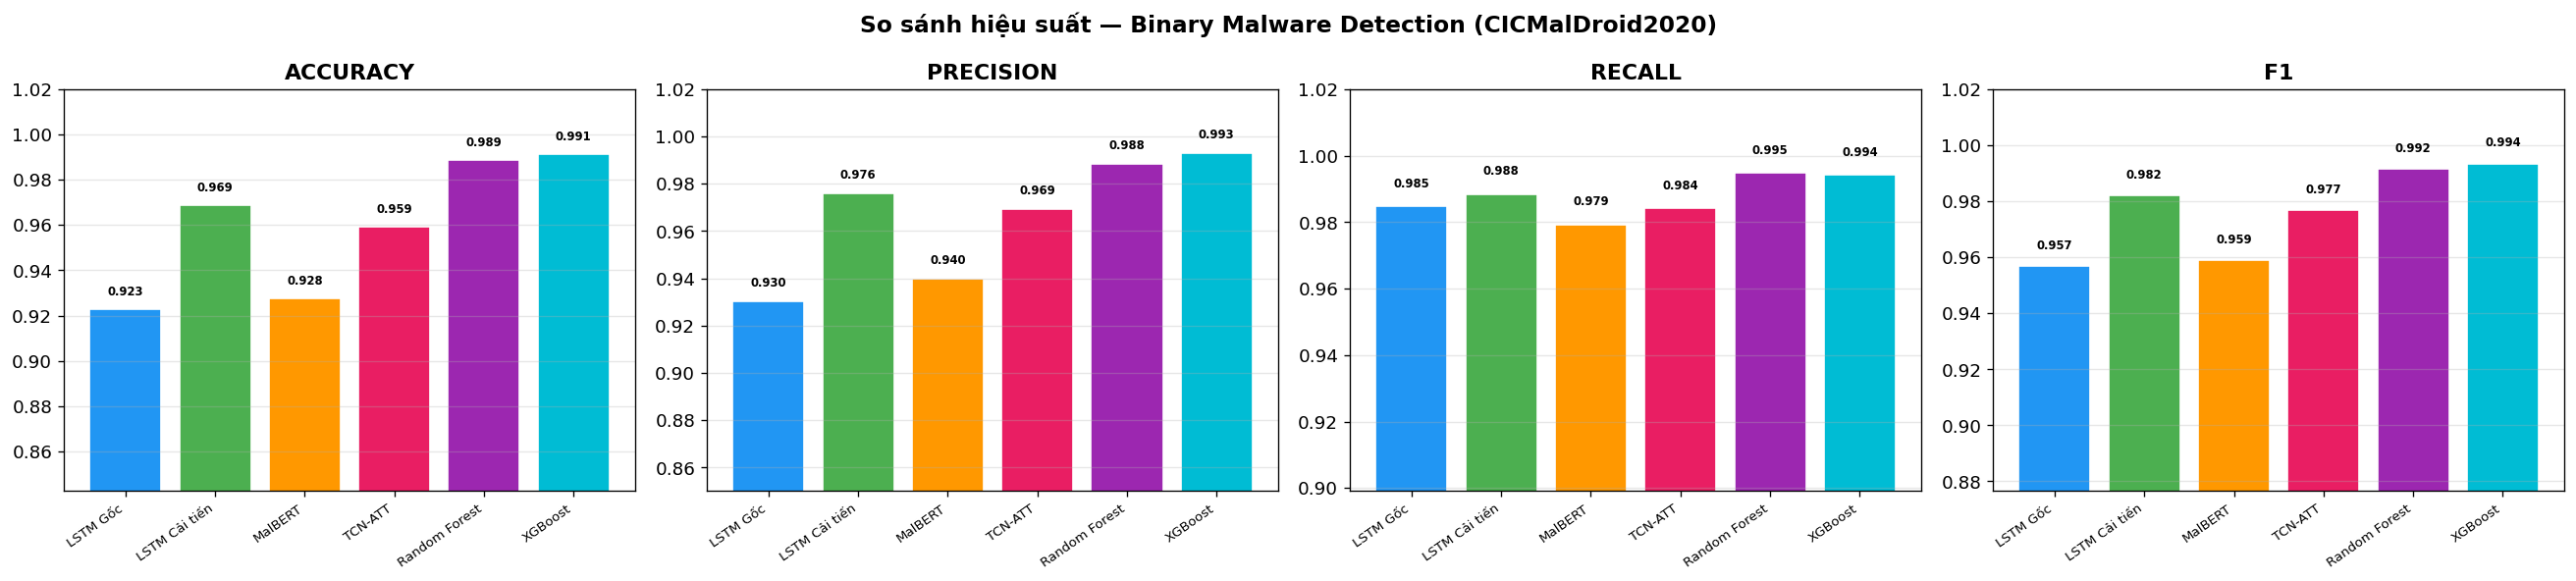

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('So sánh hiệu suất — Binary Malware Detection (CICMalDroid2020)',
             fontsize=14, fontweight='bold')

names = list(all_results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for idx, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    values = [all_results[m][metric] for m in names]
    bars = axes[idx].bar(range(len(names)), values, color=colors, edgecolor='white')
    axes[idx].set_title(metric.upper(), fontweight='bold')
    axes[idx].set_xticks(range(len(names)))
    axes[idx].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
    axes[idx].set_ylim(max(min(values)-0.08, 0), 1.02)
    axes[idx].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig1_metrics_bars.png", dpi=200, bbox_inches='tight')
plt.show()

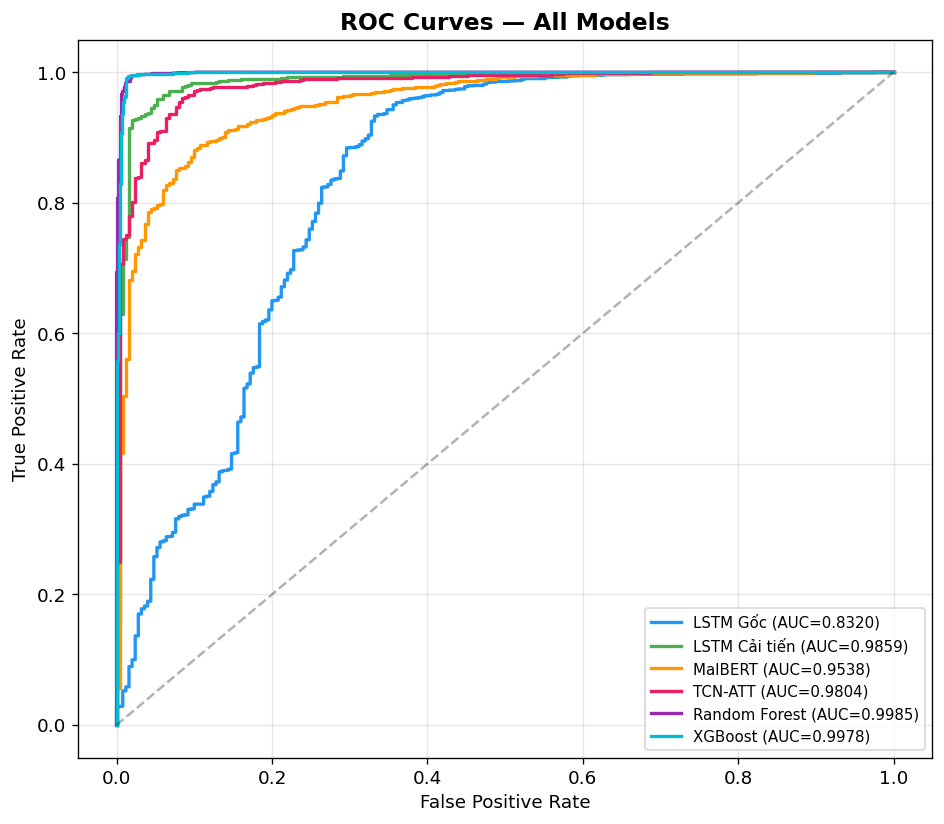

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, (name, res) in enumerate(all_results.items()):
    fpr, tpr, _ = roc_curve(test_labels[name], res['Y_prob'])
    ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
            label=f"{name} (AUC={res['auc']:.4f})")

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig2_roc_curves.png", dpi=200, bbox_inches='tight')
plt.show()

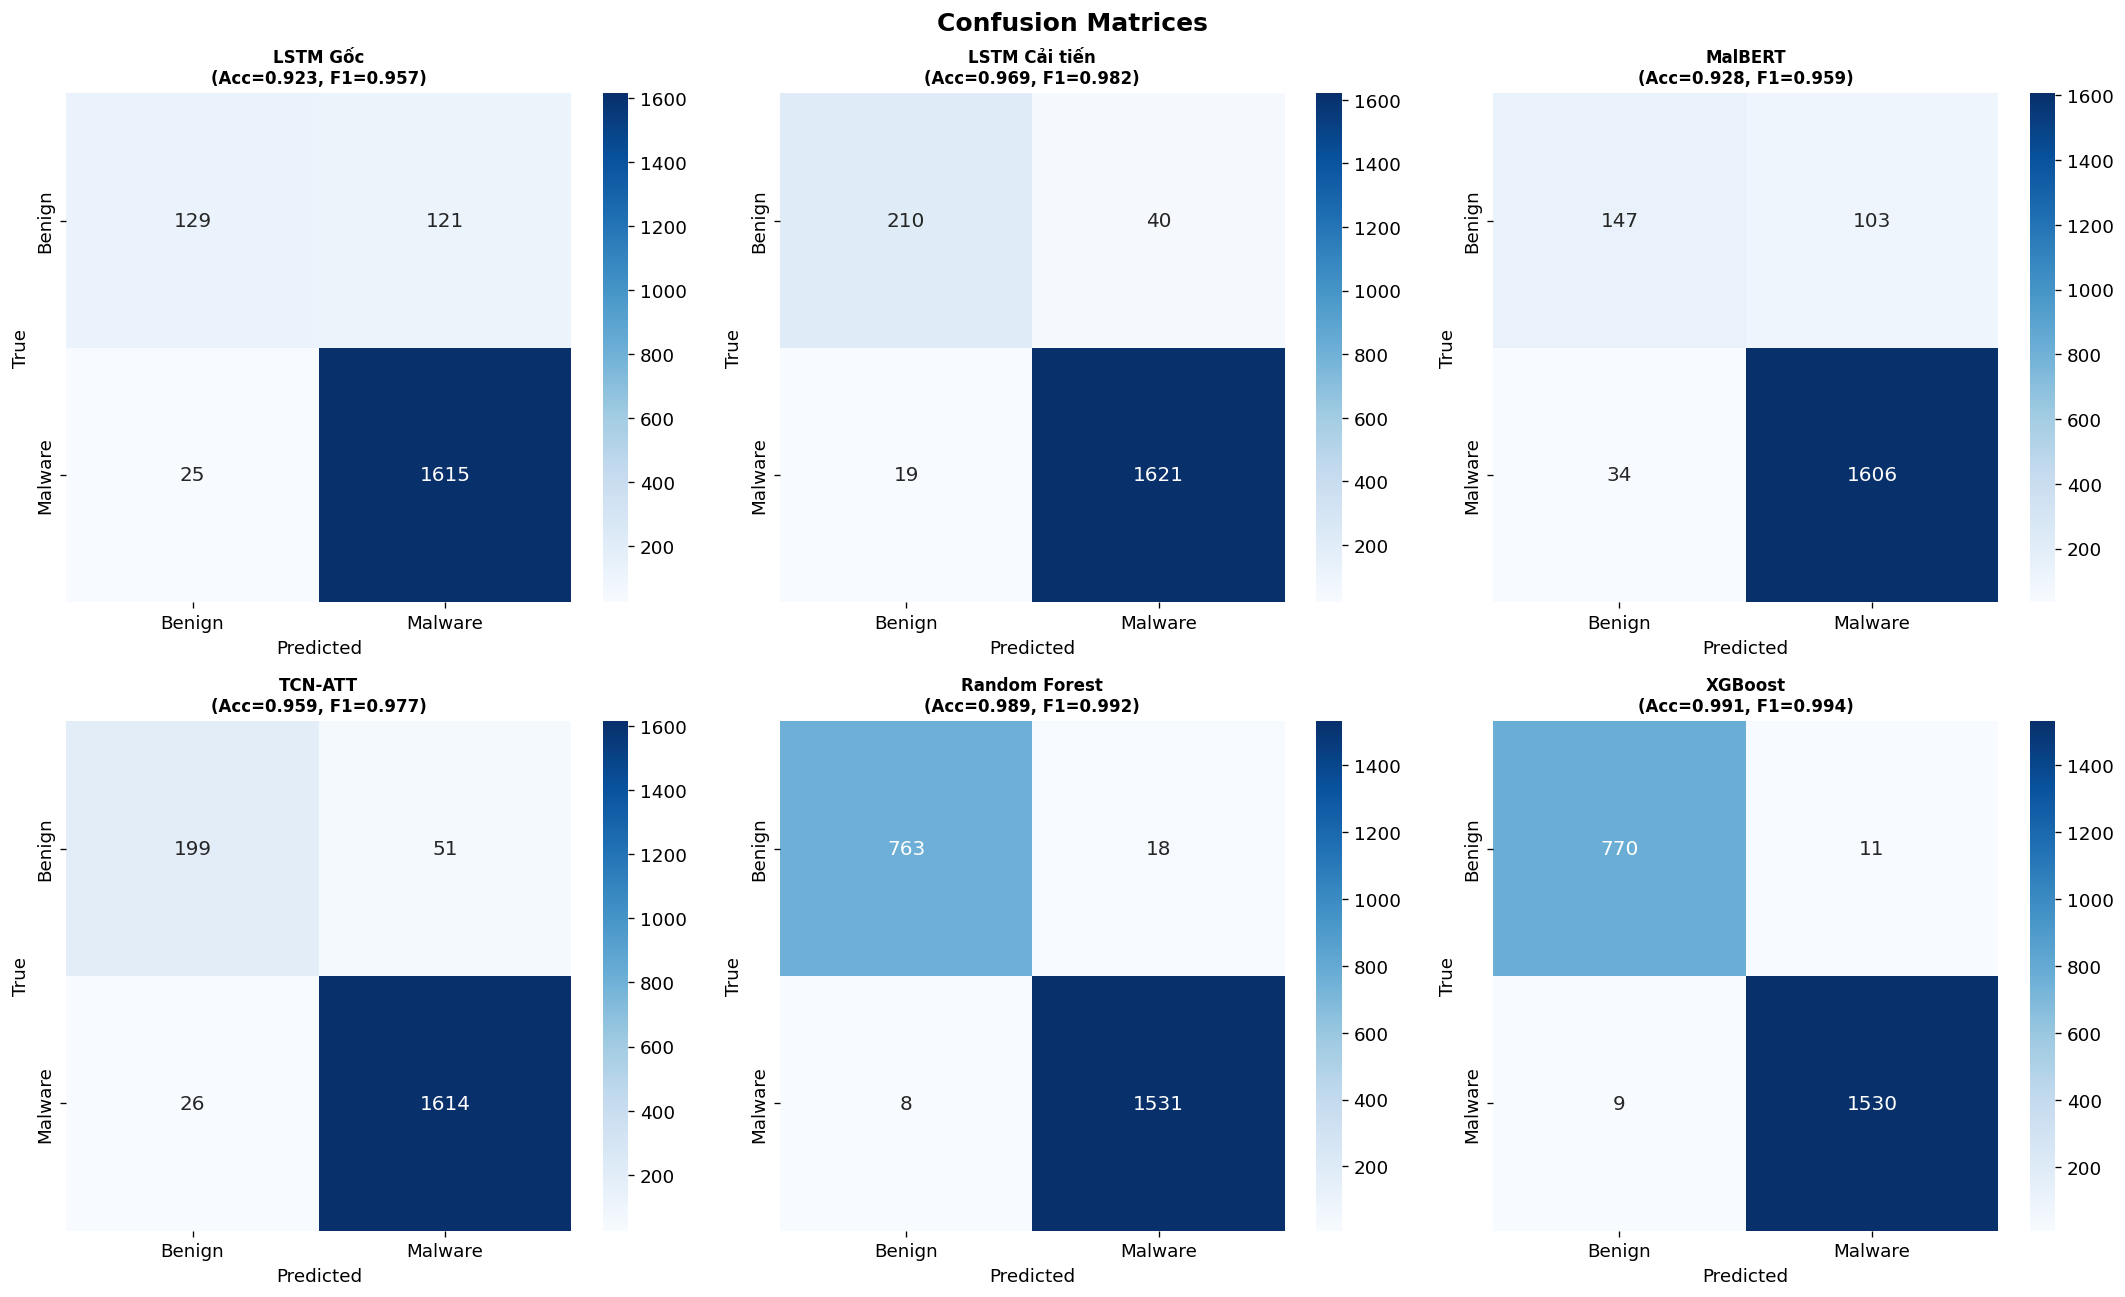

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
label_names = ['Benign', 'Malware']

for idx, (name, res) in enumerate(all_results.items()):
    row, col = divmod(idx, 3)
    cm = confusion_matrix(test_labels[name], res['Y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row][col],
                xticklabels=label_names, yticklabels=label_names, annot_kws={'size':12})
    axes[row][col].set_title(f'{name}\n(Acc={res["accuracy"]:.3f}, F1={res["f1"]:.3f})',
                              fontweight='bold', fontsize=10)
    axes[row][col].set_xlabel('Predicted')
    axes[row][col].set_ylabel('True')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig3_confusion_matrices.png", dpi=200, bbox_inches='tight')
plt.show()

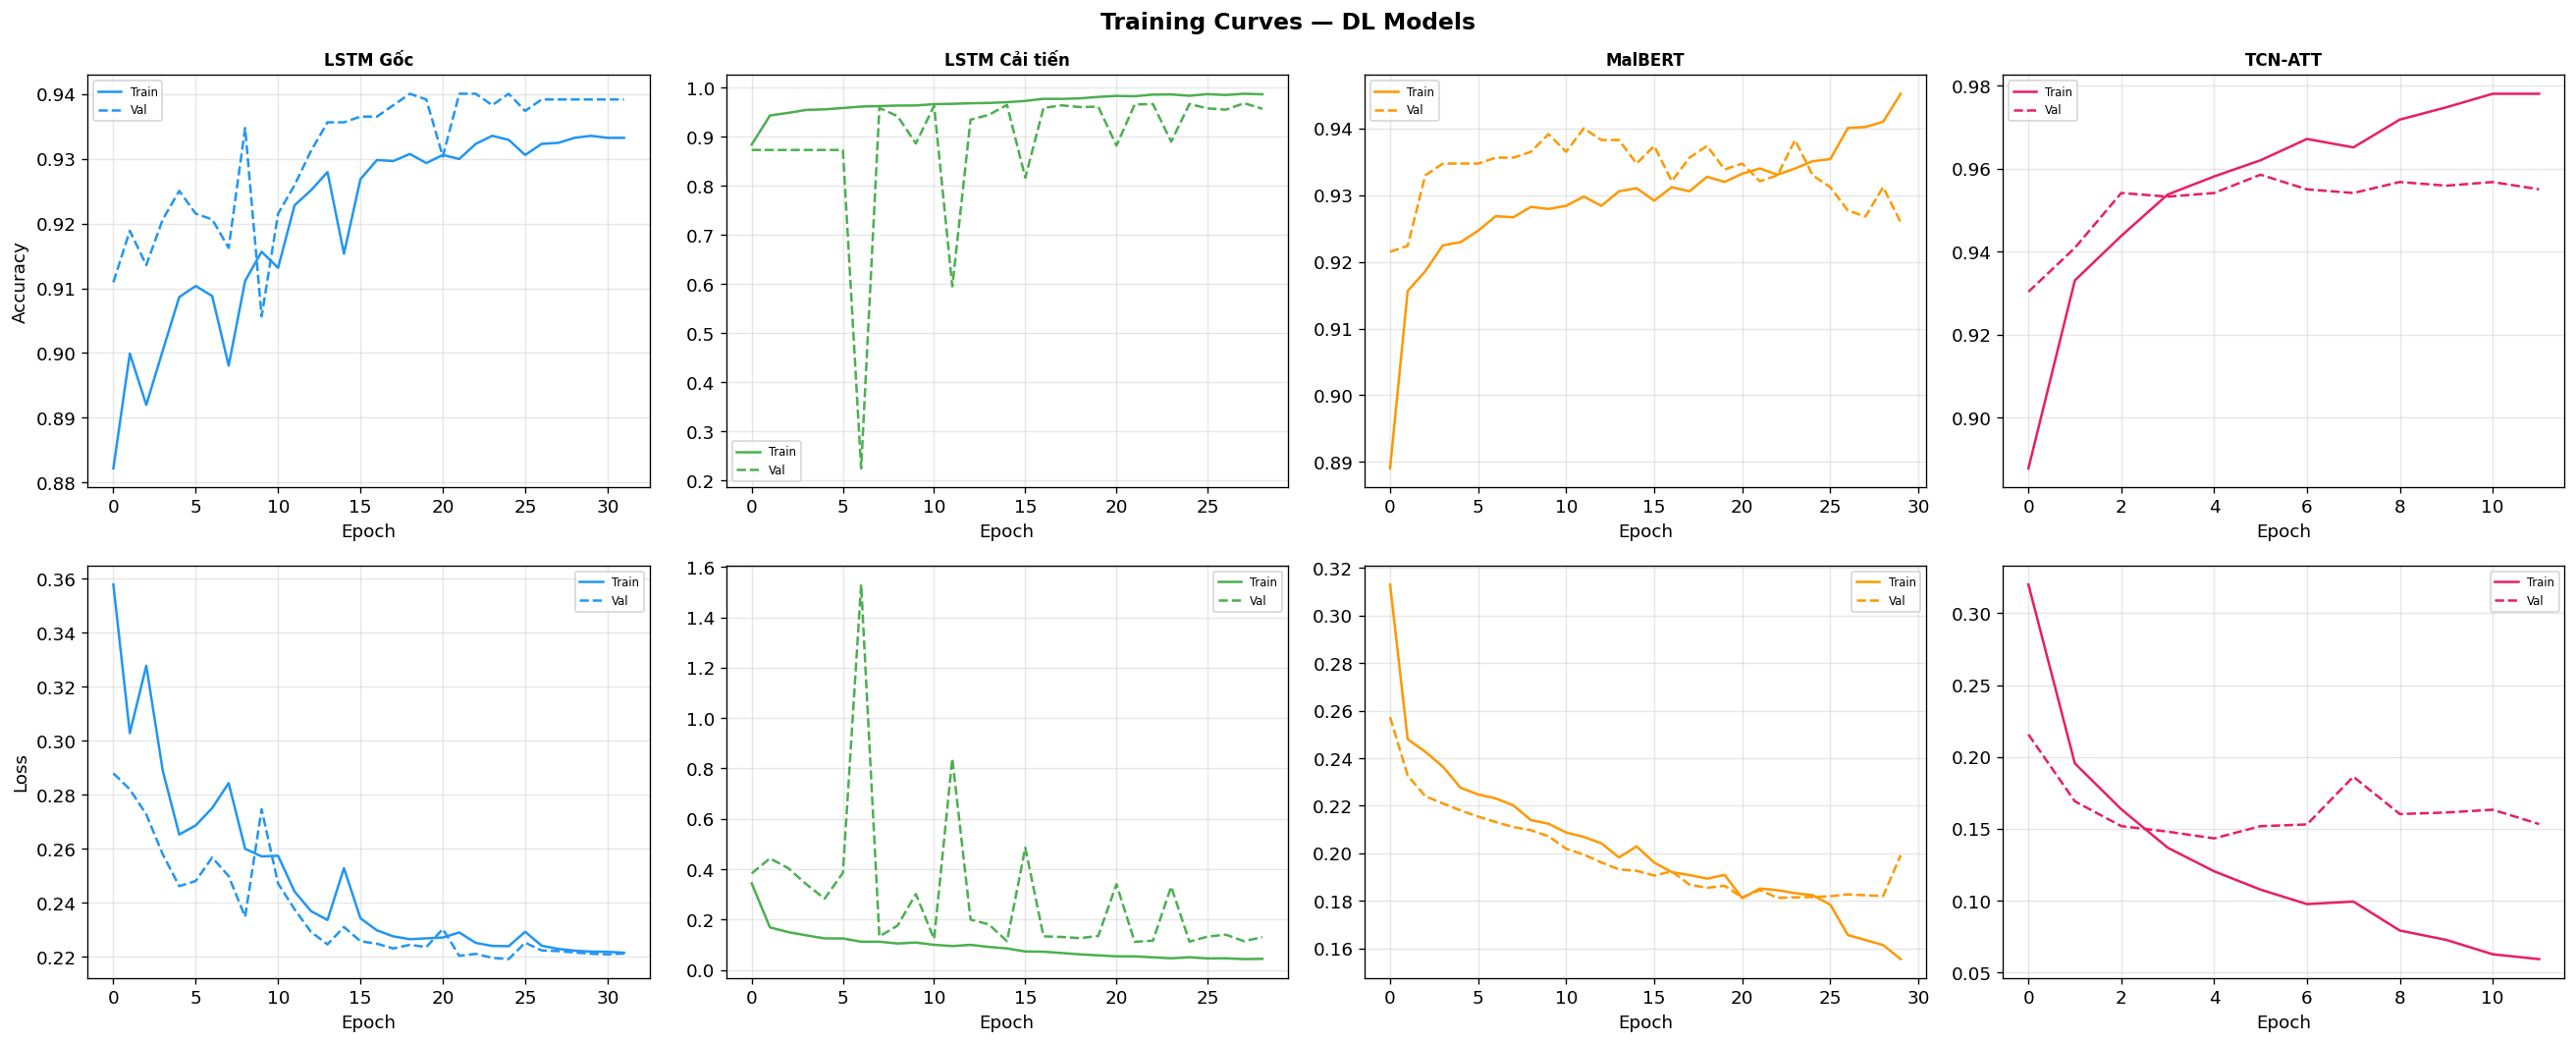

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Training Curves — DL Models', fontsize=14, fontweight='bold')
dl_names = list(dl_results.keys())
dl_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, name in enumerate(dl_names):
    h = dl_results[name]['history']
    axes[0][i].plot(h['accuracy'], label='Train', color=dl_colors[i])
    axes[0][i].plot(h['val_accuracy'], label='Val', color=dl_colors[i], ls='--')
    axes[0][i].set_title(name, fontweight='bold', fontsize=10)
    axes[0][i].set_ylabel('Accuracy' if i==0 else '')
    axes[0][i].legend(fontsize=7); axes[0][i].grid(alpha=0.3); axes[0][i].set_xlabel('Epoch')

    axes[1][i].plot(h['loss'], label='Train', color=dl_colors[i])
    axes[1][i].plot(h['val_loss'], label='Val', color=dl_colors[i], ls='--')
    axes[1][i].set_ylabel('Loss' if i==0 else '')
    axes[1][i].legend(fontsize=7); axes[1][i].grid(alpha=0.3); axes[1][i].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig4_training_curves.png", dpi=200, bbox_inches='tight')
plt.show()

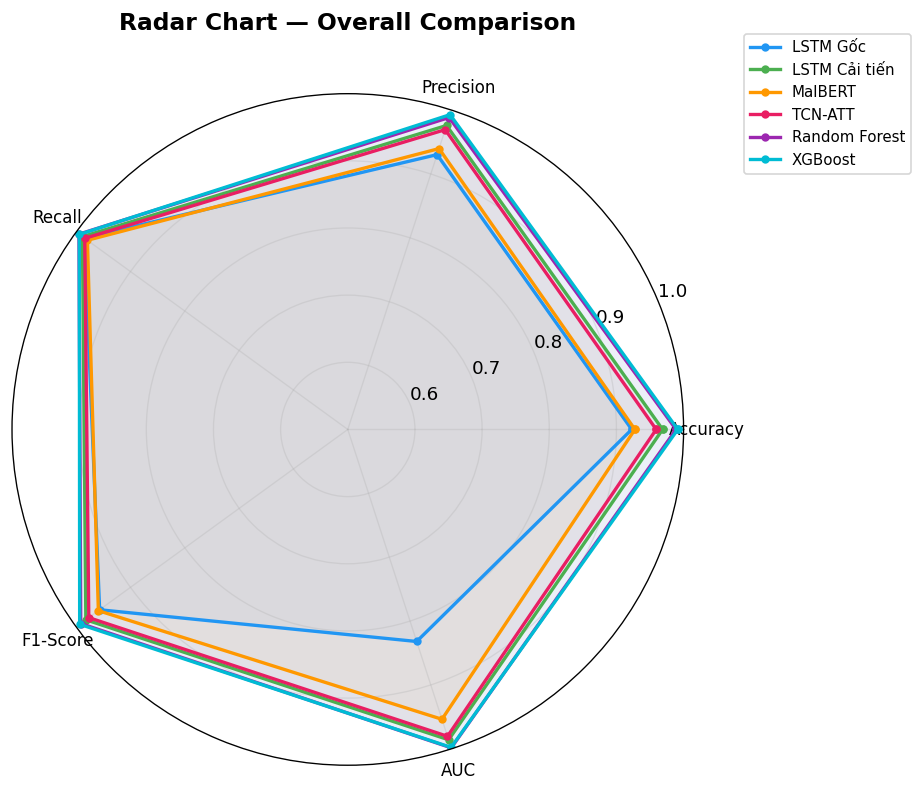

In [23]:
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N_r = len(metrics_radar)
angles = [n / float(N_r) * 2 * pi for n in range(N_r)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, (name, res) in enumerate(all_results.items()):
    vals = [res['accuracy'], res['precision'], res['recall'], res['f1'], res['auc']]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=colors_r[i], label=name, markersize=4)
    ax.fill(angles, vals, alpha=0.05, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_title('Radar Chart — Overall Comparison', fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig5_radar_chart.png", dpi=200, bbox_inches='tight')
plt.show()

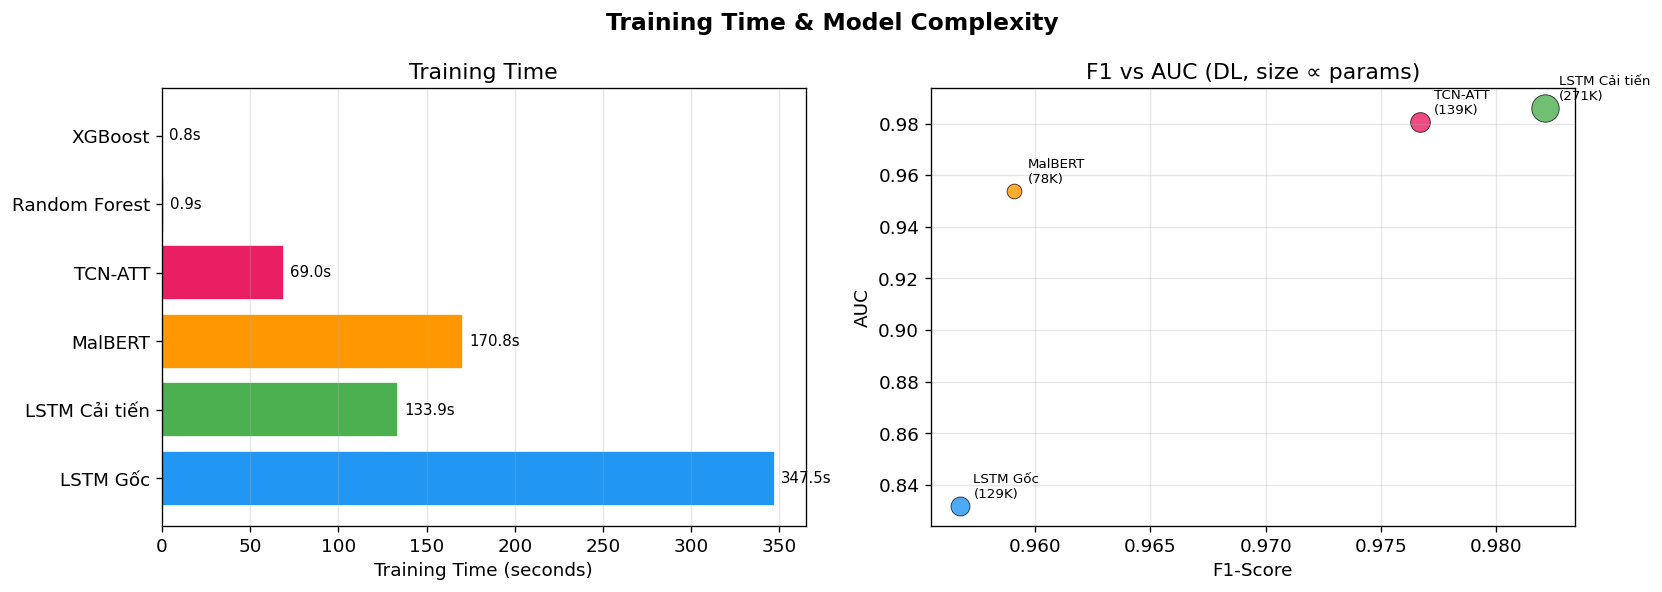

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Time & Model Complexity', fontsize=14, fontweight='bold')

names_t = list(all_results.keys())
times = [all_results[m]['train_time'] for m in names_t]
colors_t = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

bars = ax1.barh(range(len(names_t)), times, color=colors_t, edgecolor='white')
ax1.set_yticks(range(len(names_t)))
ax1.set_yticklabels(names_t)
ax1.set_xlabel('Training Time (seconds)')
ax1.set_title('Training Time'); ax1.grid(axis='x', alpha=0.3)
for bar, t in zip(bars, times):
    ax1.text(bar.get_width()+max(times)*0.01, bar.get_y()+bar.get_height()/2,
             f'{t:.1f}s', va='center', fontsize=9)

dl_only = {k: v for k, v in all_results.items() if v['n_params'] != 'N/A'}
for i, (name, res) in enumerate(dl_only.items()):
    sz = max(res['n_params']/1000, 50)
    ax2.scatter(res['f1'], res['auc'], s=sz, color=colors_t[i], alpha=0.8,
                edgecolors='black', linewidth=0.5)
    ax2.annotate(f"{name}\n({res['n_params']//1000}K)", (res['f1'], res['auc']),
                 textcoords='offset points', xytext=(8,5), fontsize=8)
ax2.set_xlabel('F1-Score'); ax2.set_ylabel('AUC')
ax2.set_title('F1 vs AUC (DL, size ∝ params)'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/fig6_time_complexity.png", dpi=200, bbox_inches='tight')
plt.show()

In [25]:
print("\n" + "═"*95)
print("  TỔNG HỢP — BINARY MALWARE DETECTION trên CICMalDroid2020")
print("═"*95)
print(f"{'Model':<18s} {'Acc':>8s} {'Prec':>8s} {'Recall':>8s} {'F1':>8s} {'AUC':>8s} {'Time':>10s} {'Params':>12s}")
print("─"*95)

best_f1 = max(all_results.values(), key=lambda x: x['f1'])['f1']
for name, res in all_results.items():
    star = ' ⭐' if res['f1'] == best_f1 else ''
    ps = f"{res['n_params']:,}" if res['n_params'] != 'N/A' else 'N/A'
    print(f"{name:<18s} {res['accuracy']:>8.4f} {res['precision']:>8.4f} "
          f"{res['recall']:>8.4f} {res['f1']:>8.4f} {res['auc']:>8.4f} "
          f"{res['train_time']:>8.1f}s {ps:>12s}{star}")

print("─"*95)
print("⭐ = Best F1-Score")
print("═"*95)


═══════════════════════════════════════════════════════════════════════════════════════════════
  TỔNG HỢP — BINARY MALWARE DETECTION trên CICMalDroid2020
═══════════════════════════════════════════════════════════════════════════════════════════════
Model                   Acc     Prec   Recall       F1      AUC       Time       Params
───────────────────────────────────────────────────────────────────────────────────────────────
LSTM Gốc             0.9228   0.9303   0.9848   0.9568   0.8320    347.5s      129,178
LSTM Cải tiến        0.9688   0.9759   0.9884   0.9821   0.9859    133.9s      271,170
MalBERT              0.9275   0.9397   0.9793   0.9591   0.9538    170.8s       78,338
TCN-ATT              0.9593   0.9694   0.9841   0.9767   0.9804     69.0s      139,778
Random Forest        0.9888   0.9884   0.9948   0.9916   0.9985      0.9s          N/A
XGBoost              0.9914   0.9929   0.9942   0.9935   0.9978      0.8s          N/A ⭐
────────────────────────────────────────

In [26]:
summary = {
    'dataset': 'CICMalDroid2020',
    'task': 'Binary Classification (Benign vs Malware)',
    'max_len': MAX_LEN, 'test_size': TEST_SIZE,
}
for name, res in all_results.items():
    key = name.replace(' ', '_').lower()
    summary[key] = {
        'accuracy': float(res['accuracy']), 'precision': float(res['precision']),
        'recall': float(res['recall']), 'f1': float(res['f1']),
        'auc': float(res['auc']), 'train_time': float(res['train_time']),
        'n_params': res['n_params'] if res['n_params'] != 'N/A' else None,
    }
with open(f"{SAVE_DIR}/all_results_summary.json", 'w') as f:
    _json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"\n📁 Saved to: {SAVE_DIR}")
for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in sorted(files):
        sz = os.path.getsize(os.path.join(root, file)) / 1024 / 1024
        print(f"{'  '*(level+1)}{file} ({sz:.2f} MB)")
print("\n✅ HOÀN THÀNH!")


📁 Saved to: /content/drive/MyDrive/MalwareDetection/MultiModel_Results/
/
  all_results_summary.json (0.00 MB)
  comparison_results.csv (0.00 MB)
figures/
  fig1_metrics_bars.png (0.19 MB)
  fig2_roc_curves.png (0.13 MB)
  fig3_confusion_matrices.png (0.23 MB)
  fig4_training_curves.png (0.47 MB)
  fig5_radar_chart.png (0.31 MB)
  fig6_time_complexity.png (0.13 MB)
models/
  LSTM_Cải_tiến.keras (3.17 MB)
  LSTM_Gốc.keras (1.52 MB)
  MalBERT.keras (1.71 MB)
  TCN-ATT.keras (1.72 MB)

✅ HOÀN THÀNH!
